In [16]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from cvar_test import mod as cvar_mod
from cvar_test import area as cvar_area
from risk_neutral_test import mod as risk_neutral_mod
from risk_neutral_test import area as risk_neutral_area
from summagasin_test import mod as summag_mod
from summagasin_test import area as summag_area

In [3]:
cvar_rsv_vols = cvar_mod.reservoirVolume.get()
risk_neutral_rsv_vols = risk_neutral_mod.reservoirVolume.get()
summag_rsv_vols = summag_mod.reservoirVolume.get()

cvar_water_values = cvar_area.water_value_result.get()
risk_neutral_water_values = risk_neutral_area.water_value_result.get()
summag_water_values = summag_area.water_value_result.get()
    
cvar_prod = cvar_area.total_production.get().to_numpy()
risk_neutral_prod = risk_neutral_area.total_production.get().to_numpy()


cvar_price = cvar_area.price.get().to_numpy()
risk_neutral_price = risk_neutral_area.price.get().to_numpy()

energy_conv = cvar_mod.energyEquivalentConst.get()

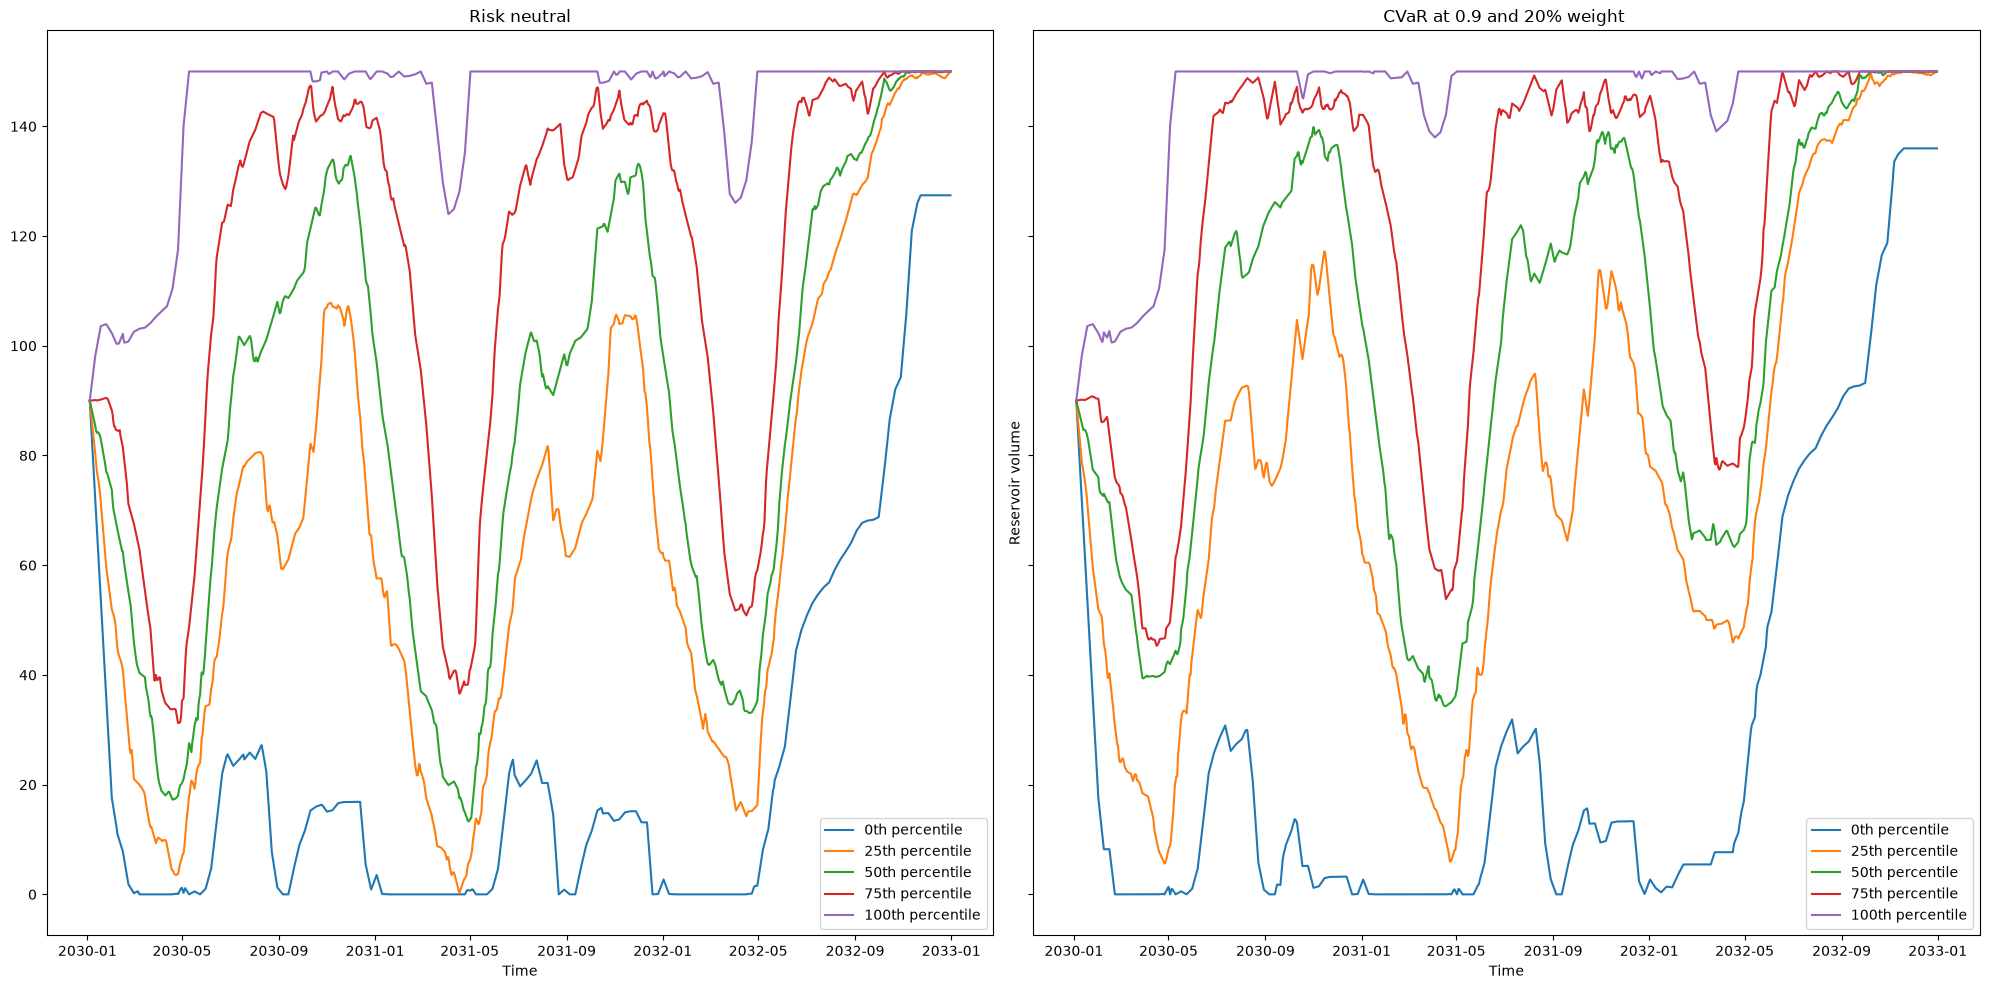

In [4]:
percs = [0, 25, 50, 75, 100]
cvar_perc_values = np.percentile(cvar_rsv_vols.values, percs, axis=1)
risk_neutral_perc_values = np.percentile(risk_neutral_rsv_vols.values, percs, axis=1)

fig, axes = plt.subplots(1, 2, figsize=(20, 10), sharey=True)

for p, values in zip(percs, risk_neutral_perc_values):
    axes[0].plot(risk_neutral_rsv_vols.index, values, label=f'{p}th percentile')
axes[0].set(title='Risk neutral', xlabel='Time')
axes[0].legend()

for p, values in zip(percs, cvar_perc_values):
    axes[1].plot(cvar_rsv_vols.index, values, label=f'{p}th percentile')
axes[1].set(title='CVaR at 0.9 and 20% weight ', ylabel='Reservoir volume', xlabel='Time')
axes[1].legend()

fig.tight_layout()

In [18]:
risk_neutral_water_val_min = risk_neutral_water_values.values[0].min() 
risk_neutral_water_val_max = risk_neutral_water_values.values[0].max() 
risk_neutral_water_val_mean = risk_neutral_water_values.values[0].mean() 
risk_neutral_water_val_std = risk_neutral_water_values.values[0].std()

cvar_water_val_min = cvar_water_values.values[0].min()
cvar_water_val_max = cvar_water_values.values[0].max()
cvar_water_val_mean = cvar_water_values.values[0].mean()
cvar_water_val_std = cvar_water_values.values[0].std()


summary_df = pd.DataFrame({
    "Min": [risk_neutral_water_val_min, cvar_water_val_min],
    "Max": [risk_neutral_water_val_max, cvar_water_val_max],
    "Mean": [risk_neutral_water_val_mean, cvar_water_val_mean],
    "STD" : [risk_neutral_water_val_std,cvar_water_val_std]
}, index=["Risk Neutral", "CVaR"])

print(summary_df)



                    Min         Max       Mean        STD
Risk Neutral  47.499847  123.993248  66.979195  16.566241
CVaR          49.943745  114.691429  67.042513  13.294037


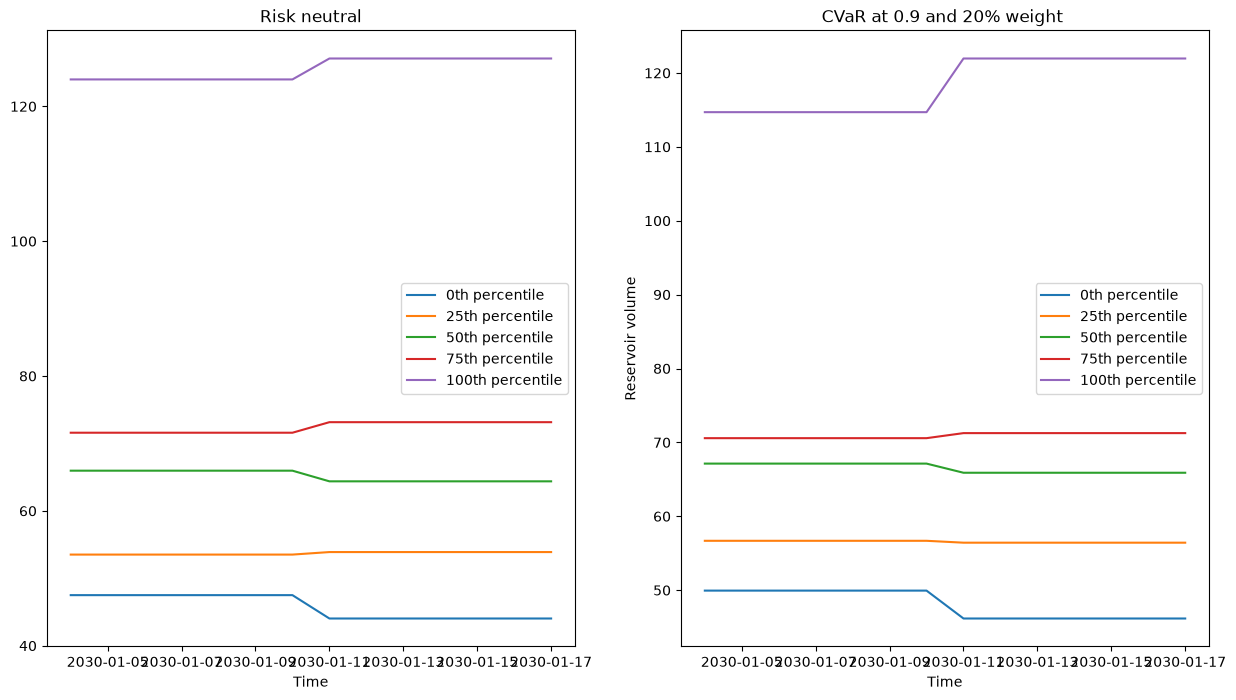

In [ ]:
percs = [0, 25, 50, 75, 100]
cvar_perc_values = np.percentile(cvar_water_values.values[:7], percs, axis=1)
risk_neutral_perc_values = np.percentile(risk_neutral_water_values.values[:7], percs, axis=1)

fig, axes = plt.subplots(1,2, figsize=(15, 8))
for p, values in zip(percs, risk_neutral_perc_values):
    axes[0].plot(risk_neutral_water_values.index[:7], values, label=f'{p}th percentile')
axes[0].set(title='Risk neutral', xlabel='Time')
axes[0].legend()

for p, values in zip(percs, cvar_perc_values):
    axes[1].plot(cvar_water_values.index[:7], values, label=f'{p}th percentile')
axes[1].set(title='CVaR at 0.9 and 20% weight ', ylabel='Reservoir volume', xlabel='Time')
axes[1].legend()

In [6]:
nscenarios = 30
nweeks = 156

cvar_vol = cvar_rsv_vols.to_numpy()
risk_neutral_vol = risk_neutral_rsv_vols.to_numpy()


cvar_income = 0
endVol = 0
startVol = 0
for i in range(nscenarios):
    for j in range(nweeks):
        cvar_income += cvar_prod[j, i] * cvar_price[j, i]       #unit is in 1000 EUR
    endVol += cvar_vol[-1, i]*cvar_price[:,i].mean() * energy_conv
    startVol += cvar_vol[0, i]*cvar_price[:,i].mean() * energy_conv
adjusted_cvar_income = (cvar_income + endVol - startVol)/nscenarios
cvar_income /= nscenarios


risk_neutral_income = 0
endVol = 0
startVol = 0
for i in range(nscenarios):
    for j in range(nweeks):
        risk_neutral_income += risk_neutral_prod[j, i] * risk_neutral_price[j, i]
    endVol += risk_neutral_vol[-1, i]*risk_neutral_price[:,i].mean() * energy_conv
    startVol += risk_neutral_vol[0, i]*risk_neutral_price[:,i].mean() * energy_conv
adjusted_risk_neutral_income = (risk_neutral_income + endVol - startVol)/nscenarios
risk_neutral_income /= nscenarios

print(f'Average income for CVaR: {cvar_income:.2f}')
print(f'Average income for Risk-Neutral: {risk_neutral_income:.2f}')
print(f'Adjusted average income for CVaR: {adjusted_cvar_income:.2f}')
print(f'Adjusted average income for Risk-Neutral: {adjusted_risk_neutral_income:.2f}')


print(f"Adjusted income scaled by risk-neutral income for CVaR: {100*adjusted_cvar_income / adjusted_risk_neutral_income:.2f}")





Average income for CVaR: 9209.71
Average income for Risk-Neutral: 9818.47
Adjusted average income for CVaR: 12359.42
Adjusted average income for Risk-Neutral: 12878.90
Adjusted income scaled by risk-neutral income for CVaR: 95.97


In [7]:
cvar_obj = cvar_area.expected_objective_value.get()
risk_neutral_obj = risk_neutral_area.expected_objective_value.get()

print(f'CVaR objective value: {cvar_obj:.2f}')
print(f'Risk-Neutral objective value: {risk_neutral_obj:.2f}')


CVaR objective value: 503398.72
Risk-Neutral objective value: 515759.44
